# 01 · Etiquetado de regímenes

Ajusta un HMM gaussiano **solo con el tramo de entrenamiento**, ordena los estados
de calma a crisis y deja la etiqueta que los cuadernos 03 y 12 tienen que predecir.
Por el camino compara dos catálogos de features de etiquetado y enseña por qué uno
de los dos no se puede usar: esa comparación **es** el argumento del cuaderno.

**Entradas:** `data/processed/canales.parquet` · `data/raw/precios.parquet`

**Salidas:** `data/processed/regimenes.parquet` ·
`data/processed/etiquetador_regimenes.pkl` · 6 figuras en `results/figures/` ·
2 tablas en `results/metricas/`

**Tiempo:** ~2 min en CPU (dos ajustes de Baum-Welch, un barrido de cinco semillas
por catálogo y un ajuste de contraste con dos estados).

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import dataclasses
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import datos, evaluacion, regimenes

config.cargar_catalogo.cache_clear()

## 1 · Qué se etiqueta, y con qué tramo

No existe una etiqueta verdadera de régimen: es una variable latente. El HMM la
estima imponiendo **persistencia**, que es justo lo que distingue un régimen de
una racha de días nerviosos. Un clustering sin memoria parpadea.

Tres objetos que se confunden con facilidad y aquí se tratan distinto:

| objeto | ¿puede mirar al futuro? | por qué |
|---|---|---|
| los canales de `X` | **nunca** | son la entrada; leer el futuro sería hacer trampa |
| la etiqueta `regimen_futuro` | **sí, por definición** | es exactamente lo que se quiere predecir |
| los **parámetros** del HMM | nunca | ajustarlos con test filtraría el test a las etiquetas |

Por eso el HMM se ajusta solo hasta 2018 y después se aplica congelado: en 2018
nadie había visto el COVID ni 2022.

In [3]:
canales = pd.read_parquet(src.DIR_PROCESADO / "canales.parquet")
precios = datos.cargar_precios()
particiones = config.particiones()

catalogo = config.cargar_catalogo()["regimenes"]
etiquetado = canales[catalogo["features_etiquetado"]]
train = etiquetado.loc[:particiones.train_hasta]

print("Features de etiquetado:", ", ".join(etiquetado.columns))
print("Ajuste:", train.index[0].date(), "a", train.index[-1].date(), "·", len(train), "de", len(etiquetado), "sesiones")
print("Estados:", catalogo["n_estados"], "· covarianza", catalogo["covarianza"], "· semillas", catalogo["semillas"])

Features de etiquetado: ret_sp500, vol_realizada_z, vix_nivel_z
Ajuste: 2004-02-02 a 2018-12-31 · 3755 de 5670 sesiones
Estados: 3 · covarianza full · semillas [42, 43, 44, 45, 46]


## 2 · El control que hay que superar antes de generar nada

El HMM converge siempre. Que converja no dice nada sobre si lo que ha encontrado
son regímenes de mercado o una partición cualquiera. Antes de entrenar un solo
generador hay que comprobar dos cosas, y las dos son bloqueantes:

| control | criterio | por qué ese número |
|---|---|---|
| las bandas de crisis caen sobre 2008, 2020 y 2022 | ≥ 50 % de los días de cada episodio | son las tres crisis que nadie discute; si el modelo no las marca, no mide estrés |
| la clase de crisis no es residual ni mayoritaria | entre el 3 % y el 20 % | por debajo del 3 % no hay con qué entrenar; por encima del 20 % el estado extremo ya no separa crisis de corrección y el taller se queda sin motivo |

Los episodios viven en `regimenes.EPISODIOS_REFERENCIA` y no en el catálogo, a
propósito: moverlos para que el control pase sería el fraude que el control existe
para impedir.

Empezamos por el conjunto de cinco features con el que arrancó el proyecto.
**Suspende.**

In [4]:
originales = list(etiquetado.columns) + catalogo["features_descartadas"]

rechazado = regimenes.EtiquetadorRegimenes.desde_catalogo()
rechazado.fit(canales[originales].loc[:particiones.train_hasta])
regimen_rechazado = rechazado.predict(canales[originales])
futuro_rechazado = regimenes.regimen_dominante(regimen_rechazado, config.ventanas().horizonte)
control_rechazado = regimenes.control_bloqueante(regimen_rechazado, futuro_rechazado, rechazado.n_estados)

_r21 = canales["ret_sp500"].loc["2021"]
print("Conjunto original, cinco features:", ", ".join(originales))
print("Sesiones de 2021 etiquetadas como crisis: {:.0f} %, y 2021 cerró {:+.1f} % con volatilidad del {:.0f} %".format(
    100 * (regimen_rechazado.loc["2021"] == rechazado.estado_crisis).mean(),
    100 * np.expm1(_r21.sum()), 100 * _r21.std() * np.sqrt(252)))
control_rechazado

Conjunto original, cinco features: ret_sp500, vol_realizada_z, vix_nivel_z, drawdown_sp500, spread_credito_z
Sesiones de 2021 etiquetadas como crisis: 40 %, y 2021 cerró +26.9 % con volatilidad del 13 %


,medido,criterio,ok
control,,,
cubre GFC 2008,100.0,50 % o mas,True
cubre COVID 2020,96.0,50 % o mas,True
cubre Inflación 2022,44.0,50 % o mas,False
peso de la clase de crisis,19.0,entre 3 % y 20 %,True


## 3 · Las dos features que lo rompen

Un HMM gaussiano supone que dentro de cada estado las observaciones son normales
y estacionarias. Dos de las cinco rompen ese supuesto, cada una a su manera:

| feature | patología | qué se mide |
|---|---|---|
| `spread_credito_z` | **deriva** — el z-score expanding no vuelve nunca de 2008 y desde 2013 vive pegado a su techo | salto de la media entre las dos mitades de la muestra, en sigmas |
| `drawdown_sp500` | **saturación** — está acotado por cero y casi la mitad de los días vale prácticamente cero | % de sesiones en el 5 % superior de su recorrido |

Con ellas dentro, el estado extremo deja de significar "mercado en tensión" y pasa
a significar "estamos en la segunda mitad de la muestra".

- Los dos umbrales (0,5 sigmas de deriva, 10 % de saturación) son convenciones
  calibradas sobre este panel, no teoremas.
- La prueba es necesaria, no suficiente: una feature puede pasarla y aun así no
  aportar información de régimen. Eso solo lo dice el control bloqueante.
- Que una feature no sirva para *etiquetar* no dice nada sobre si sirve como
  *entrada*: las dos siguen dentro de `X` (D6, un HMM gaussiano de tres estados,
  `docs/DECISIONES.md`).

In [5]:
# El diagnóstico se mide sobre el PANEL COMPLETO, no sobre train: la deriva y la
# saturación son propiedades de la serie entera, y mirar solo train las escondería.
print("Deriva: salto de la media entre las dos mitades del panel, en sigmas · umbral 0,5.")
print("Saturación: % de sesiones en el 5 % superior del recorrido · umbral 10 %.")
diag = regimenes.diagnostico_features(canales[originales])
diag

Deriva: salto de la media entre las dos mitades del panel, en sigmas · umbral 0,5.
Saturación: % de sesiones en el 5 % superior del recorrido · umbral 10 %.


,deriva,saturacion,apta
ret_sp500,0.02,0.0,True
vol_realizada_z,0.13,0.1,True
vix_nivel_z,0.07,0.1,True
drawdown_sp500,0.65,47.4,False
spread_credito_z,1.17,21.5,False


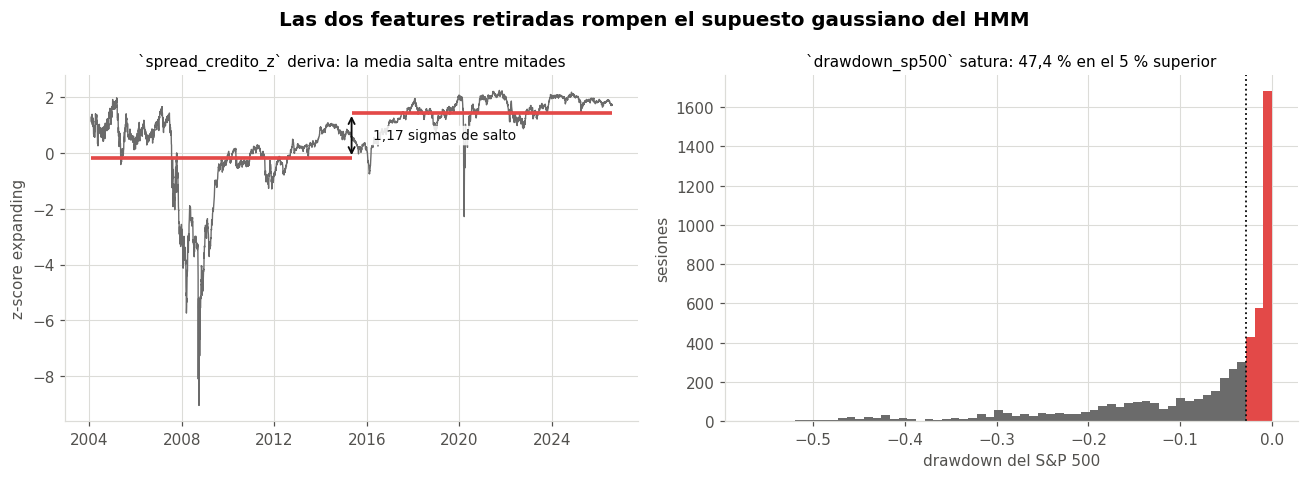

In [6]:
_s = canales["spread_credito_z"].dropna()
_m = len(_s) // 2
_a, _b = float(_s.iloc[:_m].mean()), float(_s.iloc[_m:].mean())
_dd = canales["drawdown_sp500"].dropna()
_umbral = float(_dd.max() - 0.05 * (_dd.max() - _dd.min()))
# R12: lo que pinta la figura tiene que ser lo que mide `diagnostico_features`.
assert abs(abs(_b - _a) / _s.std() - diag.loc["spread_credito_z", "deriva"]) < 0.005
assert abs(100 * (_dd >= _umbral).mean() - diag.loc["drawdown_sp500", "saturacion"]) < 0.05

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.4))
ejes[0].plot(_s.index, _s.to_numpy(), color=viz.GRIS_CONTEXTO, linewidth=0.9)
ejes[0].hlines([_a, _b], [_s.index[0], _s.index[_m]], [_s.index[_m], _s.index[-1]],
               color=viz.PALETA[7], linewidth=2.4, zorder=4)
ejes[0].annotate("", xy=(_s.index[_m], _b), xytext=(_s.index[_m], _a),
                 arrowprops=dict(arrowstyle="<->", color=viz.TINTA_PRIMARIA, linewidth=1.2))
ejes[0].annotate("{:.2f} sigmas de salto".format(diag.loc["spread_credito_z", "deriva"]).replace(".", ","),
                 xy=(_s.index[_m], (_a + _b) / 2), xytext=(14, 0), textcoords="offset points",
                 ha="left", va="center", fontsize=9, color=viz.TINTA_PRIMARIA,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
ejes[0].set_title("`spread_credito_z` deriva: la media salta entre mitades",
                  fontsize=10, fontweight="normal")
ejes[0].set_ylabel("z-score expanding")

_n, _bordes, _barras = ejes[1].hist(_dd.to_numpy(), bins=60, color=viz.GRIS_CONTEXTO)
for _borde, _barra in zip(_bordes[:-1], _barras):
    if _borde >= _umbral:
        _barra.set_facecolor(viz.PALETA[7])
ejes[1].axvline(_umbral, color=viz.TINTA_PRIMARIA, linestyle=":", linewidth=1.2)
ejes[1].set_title("`drawdown_sp500` satura: {:.1f} % en el 5 % superior".format(
    diag.loc["drawdown_sp500", "saturacion"]).replace(".", ","), fontsize=10, fontweight="normal")
ejes[1].set_xlabel("drawdown del S&P 500")
ejes[1].set_ylabel("sesiones")
fig.suptitle("Las dos features retiradas rompen el supuesto gaussiano del HMM",
             fontsize=13, fontweight="bold")
viz.guardar(fig, "01_patologias_features")

### El veredicto no puede depender de la semilla

Baum-Welch converge a óptimos locales, así que el catálogo fija cinco semillas y
`fit` se queda con la de mayor log-verosimilitud. Eso solo es legítimo si las cinco
cuentan la misma historia. Se comprueba ajustando cada semilla por separado con los
dos catálogos y mirando **qué control falla en cada una**.

Se adelanta aquí el conjunto de tres features que el apartado 4 ajusta en serio,
porque el argumento no es una tabla sino la comparación entre las dos.

In [7]:
_ok, _peso_sem, _ll, _serie = {}, {}, {}, {}
for _tag, _cols in (("cinco", originales), ("tres", list(etiquetado.columns))):
    _X = canales[_cols]
    for _s in catalogo["semillas"]:
        _e = dataclasses.replace(regimenes.EtiquetadorRegimenes.desde_catalogo(), semillas=(_s,))
        _e.fit(_X.loc[:particiones.train_hasta])
        _r = _e.predict(_X)
        _c = regimenes.control_bloqueante(
            _r, regimenes.regimen_dominante(_r, config.ventanas().horizonte), _e.n_estados)
        _ok[(_tag, _s)], _serie[(_tag, _s)] = _c["ok"], _r
        _peso_sem[(_tag, _s)] = _c.loc["peso de la clase de crisis", "medido"]
        _ll[(_tag, _s)] = _e.modelo.score(_X.loc[:particiones.train_hasta].to_numpy())

In [8]:
_pares = list(itertools.combinations(catalogo["semillas"], 2))
_acuerdo = lambda t: min(100 * float((_serie[(t, a)] == _serie[(t, b)]).mean()) for a, b in _pares)
# R12: el barrido tiene que reproducir el ajuste rechazado de la celda 6.
_gana5 = max(catalogo["semillas"], key=lambda s: _ll[("cinco", s)])
assert _ok[("cinco", _gana5)].equals(control_rechazado["ok"]), "El barrido no reproduce el ajuste rechazado."

print("Log-verosimilitud en train por semilla, tres features:")
print("  " + " · ".join("{}: {:.4f}".format(s, _ll[("tres", s)]) for s in catalogo["semillas"]))
print("Acuerdo mínimo entre etiquetados de dos semillas · cinco features: {:.1f} % · tres features: {:.1f} %".format(
    _acuerdo("cinco"), _acuerdo("tres")))

Log-verosimilitud en train por semilla, tres features:
  42: 9418.7276 · 43: 9417.4850 · 44: 9417.4850 · 45: 9418.7470 · 46: 9417.5652
Acuerdo mínimo entre etiquetados de dos semillas · cinco features: 52.8 % · tres features: 98.9 %


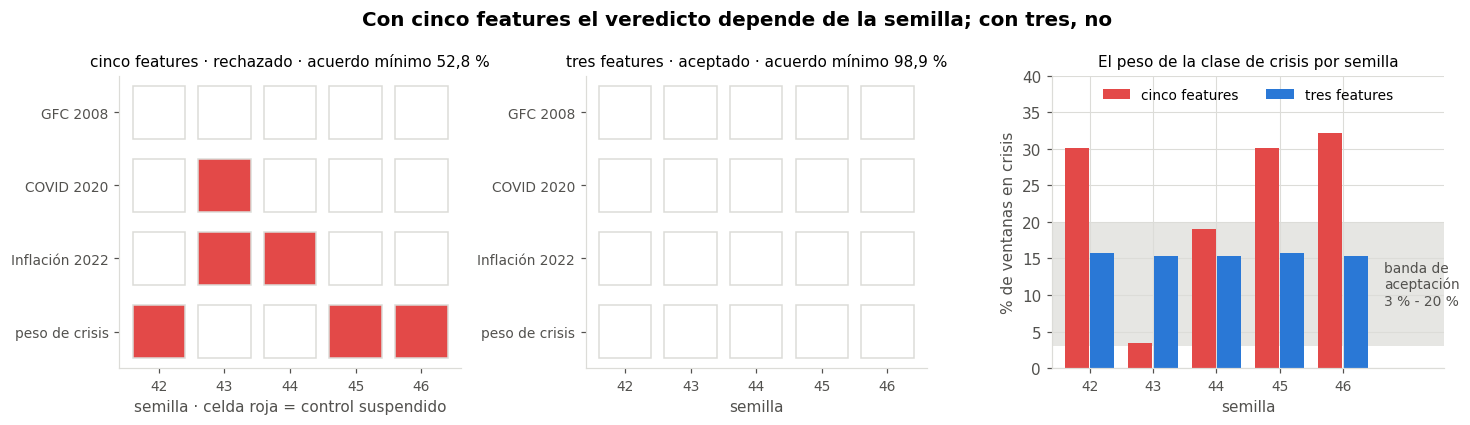

In [9]:
_corto = ["GFC 2008", "COVID 2020", "Inflación 2022", "peso de crisis"]
_sem = list(catalogo["semillas"])

fig, ejes = plt.subplots(1, 3, figsize=(13.5, 3.9), gridspec_kw={"width_ratios": [1, 1, 1.15]})
for _eje, _tag, _tit in zip(ejes[:2], ("cinco", "tres"),
                            ("cinco features · rechazado", "tres features · aceptado")):
    for _j, _s in enumerate(_sem):
        for _i, _c in enumerate(_ok[(_tag, _s)].index):
            _eje.add_patch(plt.Rectangle(
                (_j - 0.4, _i - 0.36), 0.8, 0.72, edgecolor=viz.REJILLA, linewidth=1.0,
                facecolor="none" if _ok[(_tag, _s)].iloc[_i] else viz.PALETA[7]))
    _eje.set_xlim(-0.6, len(_sem) - 0.4)
    _eje.set_ylim(len(_corto) - 0.5, -0.5)
    _eje.set_xticks(range(len(_sem)), [str(s) for s in _sem], fontsize=9)
    _eje.set_yticks(range(len(_corto)), _corto, fontsize=9)
    _eje.set_xlabel("semilla" if _tag == "tres" else "semilla · celda roja = control suspendido")
    _eje.grid(False)
    _eje.set_title("{} · acuerdo mínimo {:.1f} %".format(_tit, _acuerdo(_tag)).replace(".", ","),
                   fontsize=10, fontweight="normal")

_x = np.arange(len(_sem))
ejes[2].axhspan(3, 20, color=viz.REJILLA, alpha=0.7, lw=0, zorder=0)
ejes[2].bar(_x - 0.2, [_peso_sem[("cinco", s)] for s in _sem], width=0.38,
            color=viz.PALETA[7], label="cinco features")
ejes[2].bar(_x + 0.2, [_peso_sem[("tres", s)] for s in _sem], width=0.38,
            color=viz.PALETA[0], label="tres features")
ejes[2].set_xlim(-0.6, len(_sem) + 0.6)
ejes[2].set_ylim(0, 40)
ejes[2].set_xticks(_x, [str(s) for s in _sem], fontsize=9)
ejes[2].set_xlabel("semilla")
ejes[2].set_ylabel("% de ventanas en crisis")
ejes[2].text(len(_sem) - 0.35, 11.5, "banda de\naceptación\n3 % - 20 %", fontsize=9,
             ha="left", va="center", color=viz.TINTA_SECUNDARIA)
ejes[2].legend(fontsize=9, loc="upper center", ncols=2)
ejes[2].set_title("El peso de la clase de crisis por semilla", fontsize=10, fontweight="normal")
fig.suptitle("Con cinco features el veredicto depende de la semilla; con tres, no",
             fontsize=13, fontweight="bold")
viz.guardar(fig, "01_estabilidad_semillas")

## 4 · El etiquetado que sí pasa

Se retiran las dos y se repite el ajuste con las tres que quedan. No se toca nada
más: mismos tres estados, misma covarianza `full`, mismas cinco semillas.

El cambio arregla las dos cosas a la vez: los cuatro controles pasan y el ajuste
deja de depender de la inicialización. **Deja de depender, que no es lo mismo que
converger a la misma solución**: las cinco semillas dan log-verosimilitudes
distintas y etiquetados que no coinciden al 100 %, como acaba de imprimir el
barrido. Lo que se sostiene es lo medido —las cinco pasan los cuatro controles y
sus etiquetados coinciden casi siempre—, y con cinco features no se sostiene ni
una cosa ni la otra.

- El primer `assert` corta el cuaderno si algún control falla: no se sigue al
  cuaderno 02 con un etiquetado que no ha pasado la puerta.
- El segundo reconcilia la semilla ganadora del barrido con el ajuste oficial. Es
  la única forma de saber cuál gana de verdad: `fit` recorre las semillas en el
  orden del catálogo y compara con `>` estricto, así que un empate se lo queda la
  primera.

In [10]:
etiquetador = regimenes.EtiquetadorRegimenes.desde_catalogo()
etiquetador.fit(train)
regimen = etiquetador.predict(etiquetado)
proba = etiquetador.predict_proba(etiquetado)
regimen_futuro = regimenes.regimen_dominante(regimen, config.ventanas().horizonte)
control = regimenes.control_bloqueante(regimen, regimen_futuro, etiquetador.n_estados)

_ll_oficial = float(etiquetador.modelo.score(train.to_numpy()))
_gana3 = max(catalogo["semillas"], key=lambda s: _ll[("tres", s)])
assert control["ok"].all(), "Control bloqueante suspendido: no sigas al cuaderno 02."
assert abs(_ll_oficial - _ll[("tres", _gana3)]) < 1e-6, "El barrido no reproduce el ajuste oficial."

print("Semilla ganadora: {} · log-verosimilitud en train: {:.4f} · iteraciones del EM: {}".format(
    _gana3, _ll_oficial, etiquetador.modelo.monitor_.iter))
print(control.to_string())

Semilla ganadora: 45 · log-verosimilitud en train: 9418.7470 · iteraciones del EM: 163
                            medido          criterio    ok
control                                                   
cubre GFC 2008               100.0        50 % o mas  True
cubre COVID 2020              96.0        50 % o mas  True
cubre Inflación 2022          56.5        50 % o mas  True
peso de la clase de crisis    15.8  entre 3 % y 20 %  True


In [11]:
# Los ocho números del control, uno al lado del otro. Se lee de un vistazo y no
# necesita figura (R7): lo que suspende es la cobertura de 2022, no el peso.
pd.concat([control_rechazado["medido"].rename("cinco features"),
           control["medido"].rename("tres features"),
           control["criterio"]], axis=1)

,cinco features,tres features,criterio
control,,,
cubre GFC 2008,100.0,100.0,50 % o mas
cubre COVID 2020,96.0,96.0,50 % o mas
cubre Inflación 2022,44.0,56.5,50 % o mas
peso de la clase de crisis,19.0,15.8,entre 3 % y 20 %


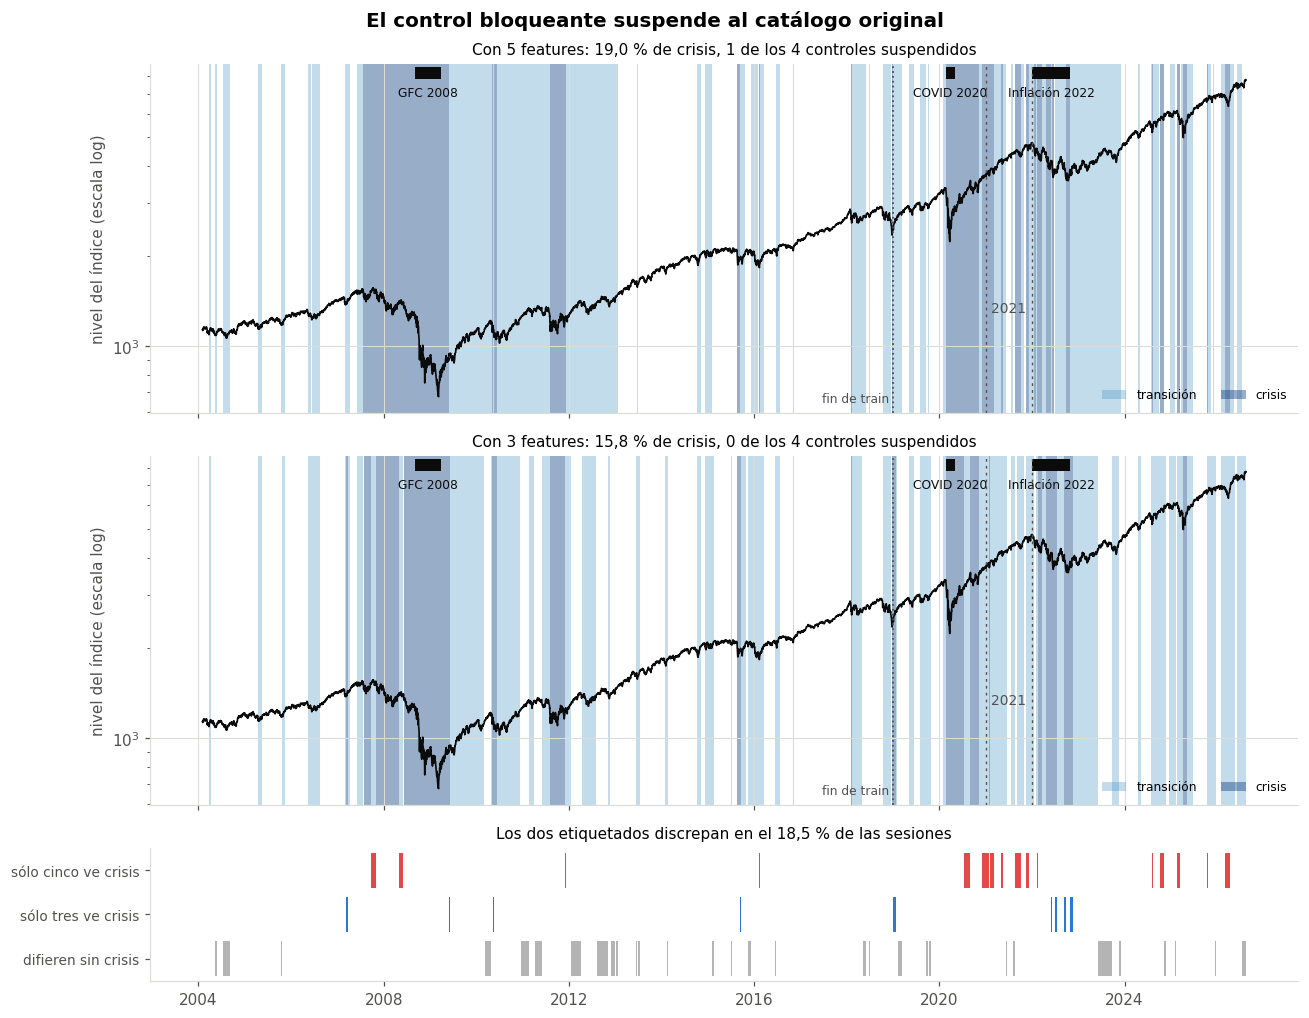

In [12]:
_ind = precios["sp500"].reindex(regimen.index)
_tit = lambda n, p, f: "Con {} features: {:.1f} % de crisis, {} de los 4 controles suspendidos".format(n, p, f).replace(".", ",")
_peso = lambda t: t.loc["peso de la clase de crisis", "medido"]
_crisis = etiquetador.estado_crisis
_solo5 = (regimen_rechazado == _crisis) & (regimen != _crisis)
_solo3 = (regimen == _crisis) & (regimen_rechazado != _crisis)
_otro = (regimen != regimen_rechazado) & ~_solo5 & ~_solo3

fig, ejes = plt.subplots(3, 1, figsize=(12, 9.4), sharex=True,
                         gridspec_kw={"height_ratios": [3, 3, 1.15]})
viz.serie_regimenes(_ind, regimen_rechazado,
                    _tit(len(originales), _peso(control_rechazado), int((~control_rechazado["ok"]).sum())),
                    episodios=regimenes.EPISODIOS_REFERENCIA, corte=particiones.train_hasta, eje=ejes[0])
viz.serie_regimenes(_ind, regimen,
                    _tit(len(etiquetado.columns), _peso(control), int((~control["ok"]).sum())),
                    episodios=regimenes.EPISODIOS_REFERENCIA, corte=particiones.train_hasta, eje=ejes[1])
for _eje in ejes[:2]:
    for _f in ("2021-01-01", "2021-12-31"):
        _eje.axvline(pd.Timestamp(_f), color=viz.TINTA_SECUNDARIA, linestyle=(0, (2, 3)),
                     linewidth=0.9, zorder=6)
    _eje.text(pd.Timestamp("2021-07-01"), 0.30, "2021", transform=_eje.get_xaxis_transform(),
              ha="center", va="center", fontsize=9, color=viz.TINTA_SECUNDARIA)
for _mascara, _y, _color, _alfa in ((_solo5, 0.70, viz.PALETA[7], 1.0),
                                    (_solo3, 0.37, viz.PALETA[0], 1.0),
                                    (_otro, 0.04, viz.GRIS_CONTEXTO, 0.5)):
    ejes[2].fill_between(regimen.index, _y, _y + 0.26, where=_mascara.to_numpy(), step="post",
                         color=_color, alpha=_alfa, lw=0)
ejes[2].set_ylim(0, 1)
ejes[2].set_yticks([0.17, 0.50, 0.83],
                   ["difieren sin crisis", "sólo tres ve crisis", "sólo cinco ve crisis"], fontsize=9)
ejes[2].grid(False)
ejes[2].set_title("Los dos etiquetados discrepan en el {:.1f} % de las sesiones".format(
    100 * float((regimen != regimen_rechazado).mean())).replace(".", ","),
    fontsize=10, fontweight="normal")
fig.suptitle("El control bloqueante suspende al catálogo original", fontsize=13, fontweight="bold")
viz.guardar(fig, "control_etiquetado")

### Dónde se equivoca el catálogo rechazado, año a año

El titular no es que el catálogo de cinco features no vea las crisis: 2008 y 2020
los cubren los dos. El problema es la **asimetría** — enciende el estado de crisis
en años tranquilos y lo apaga justo en el mercado bajista de 2022, que es el
episodio por el que suspende el control de cobertura.

**Esta es la figura que va al slide.**

- Cada barra es la diferencia entre los dos etiquetados, en puntos porcentuales de
  sesiones marcadas crisis. Las cifras absolutas de los dos años señalados las
  interpola la propia figura.
- 2008, 2020 y 2022 van en negrita: son los tres episodios de
  `regimenes.EPISODIOS_REFERENCIA` contra los que se juzga el etiquetado.
- Un año con barra a cero no significa que los dos etiqueten igual ese año, solo
  que marcan el mismo número de sesiones: el carril de desacuerdo de la figura
  anterior lo desmiente.

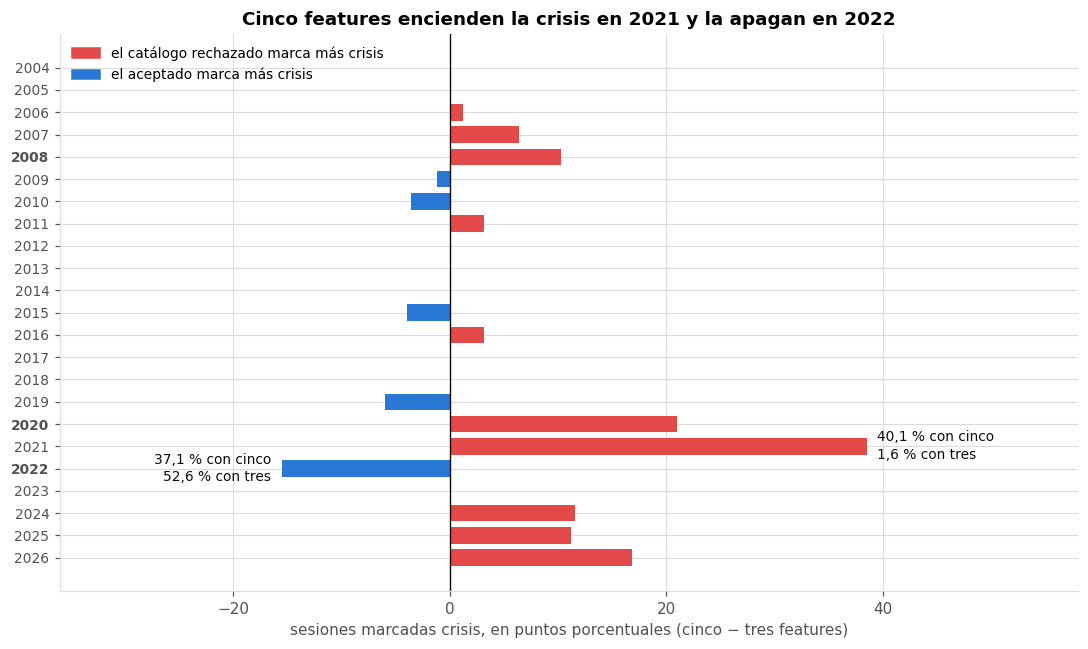

In [13]:
from matplotlib.patches import Patch

_por_anio = lambda s: (s == etiquetador.estado_crisis).groupby(s.index.year).mean().mul(100)
_tres, _cinco = _por_anio(regimen), _por_anio(regimen_rechazado)
_dif = (_cinco - _tres).sort_index()
_com = lambda v: "{:.1f} %".format(v).replace(".", ",")

fig, eje = plt.subplots(figsize=(10, 6))
_y = np.arange(len(_dif))
eje.barh(_y, _dif.to_numpy(), height=0.74,
         color=[viz.PALETA[7] if v > 0 else viz.PALETA[0] for v in _dif])
eje.set_yticks(_y, [str(a) for a in _dif.index], fontsize=9)
eje.invert_yaxis()
for _t, _a in zip(eje.get_yticklabels(), _dif.index):
    _t.set_fontweight("bold" if _a in (2008, 2020, 2022) else "normal")
eje.axvline(0, color=viz.TINTA_PRIMARIA, linewidth=0.9)
eje.set_xlim(-36, 58)
eje.set_xlabel("sesiones marcadas crisis, en puntos porcentuales (cinco − tres features)")
for _a in (2021, 2022):
    _v, _i = _dif.loc[_a], list(_dif.index).index(_a)
    eje.annotate("{} con cinco\n{} con tres".format(_com(_cinco.loc[_a]), _com(_tres.loc[_a])),
                 xy=(_v, _i), xytext=(7 if _v > 0 else -7, 0), textcoords="offset points",
                 ha="left" if _v > 0 else "right", va="center", linespacing=1.35,
                 fontsize=9, color=viz.TINTA_PRIMARIA)
eje.legend(handles=[Patch(color=viz.PALETA[7], label="el catálogo rechazado marca más crisis"),
                    Patch(color=viz.PALETA[0], label="el aceptado marca más crisis")],
           loc="upper left", fontsize=9)
eje.set_title("Cinco features encienden la crisis en 2021 y la apagan en 2022", fontsize=12)
viz.guardar(fig, "01_etiquetado_por_anio")

## 5 · Qué son los tres estados

La numeración no la elige el HMM —Baum-Welch nombra los estados en el orden en que
los encuentra— sino la canonicalización: se ordenan por volatilidad creciente, y el
retorno medio solo desempata entre estados de volatilidad parecida. Sin eso, el
estado 2 sería crisis en una ejecución y calma en la siguiente.

Las dos tablas comprueban que la numeración significa lo que dice: la volatilidad
crece de forma monótona, **solo el estado 2 pierde dinero** y `drawdown_sp500`,
retirado del ajuste, confirma el orden desde fuera. En la matriz de transición la
diagonal está muy cerca de uno: los regímenes duran meses, no días.

- La celda imprime el **mínimo** de la diagonal, que es el número honesto: los tres
  estados no son igual de persistentes y el intermedio es bastante menos.
- **Duración esperada por la matriz de transición** —1/(1−diagonal), ajustada solo
  con train— y **duración observada de las rachas** son dos cosas distintas y no
  tienen por qué coincidir: la primera supone permanencia geométrica, la segunda
  cuenta lo que pasó en el panel entero. Las dos se imprimen juntas justo para que
  se vea la diferencia.
- Las rachas contiguas de crisis del etiquetado diario tampoco son el recuento por
  particiones del cuaderno 02, que cuenta rachas de **ventanas** dentro de cada
  partición. Son objetos distintos y no se reconcilian.

In [14]:
nombres = evaluacion.nombres_regimenes(etiquetador.n_estados)
retorno = canales["ret_sp500"]
estados = range(etiquetador.n_estados)

perfil = pd.DataFrame({
    "sesiones": [int((regimen == k).sum()) for k in estados],
    "ret. anualizado": [retorno[regimen == k].mean() * 252 for k in estados],
    "vol. anualizada": [retorno[regimen == k].std() * np.sqrt(252) for k in estados],
    "vix_nivel_z": [canales["vix_nivel_z"][regimen == k].mean() for k in estados],
    "drawdown": [canales["drawdown_sp500"][regimen == k].mean() for k in estados],
}, index=nombres)

print("Rachas contiguas de crisis · etiquetado diario: {} · etiqueta a {} días: {}".format(
    regimenes.tramos_contiguos(regimen, etiquetador.estado_crisis),
    config.ventanas().horizonte,
    regimenes.tramos_contiguos(regimen_futuro.dropna(), etiquetador.estado_crisis)))
perfil.round(3)

Rachas contiguas de crisis · etiquetado diario: 18 · etiqueta a 21 días: 14


,sesiones,ret. anualizado,vol. anualizada,vix_nivel_z,drawdown
calma,2609,0.165,0.091,-0.706,-0.028
transición,2160,0.124,0.159,0.028,-0.097
crisis,901,-0.236,0.370,1.724,-0.203


In [15]:
transicion = pd.DataFrame(
    etiquetador.modelo.transmat_[np.ix_(etiquetador.orden, etiquetador.orden)],
    index=nombres, columns=nombres).rename_axis(index="desde", columns="hacia")
duracion = pd.Series(1.0 / (1.0 - np.diag(transicion.to_numpy())), index=nombres)

_rachas = regimen.groupby(regimen.ne(regimen.shift()).cumsum())
_observada = pd.Series({nombres[k]: float(np.median([len(t) for _, t in _rachas if int(t.iloc[0]) == k]))
                        for k in estados})

print("Mínimo de la diagonal de la matriz de transición: {:.4f}".format(
    float(np.diag(transicion.to_numpy()).min())))
print("Duración esperada por la matriz, en sesiones (ajustada solo con train) ·",
      " · ".join("{} {:.0f}".format(n, v) for n, v in duracion.items()))
print("Duración mediana observada de las rachas, en sesiones ·",
      " · ".join("{} {:.0f}".format(n, v) for n, v in _observada.items()))
transicion.round(3)

Mínimo de la diagonal de la matriz de transición: 0.9698
Duración esperada por la matriz, en sesiones (ajustada solo con train) · calma 77 · transición 33 · crisis 72
Duración mediana observada de las rachas, en sesiones · calma 55 · transición 30 · crisis 26


hacia,calma,transición,crisis
desde,,,
calma,0.987,0.013,0.000
transición,0.022,0.970,0.008
crisis,0.000,0.014,0.986


### ¿Y por qué no dos estados?

D6 (tres estados y no dos, `docs/DECISIONES.md`) descartaba la versión de dos
citando un TFM sobre otro panel. Aquí se mide sobre éste: se reajusta el mismo HMM
con `n_estados=2` y se pasa el mismo control bloqueante. Cuesta unos segundos y
convierte una cita prestada en una medición propia. El veredicto lo imprime la
celda.

In [16]:
_dos = dataclasses.replace(regimenes.EtiquetadorRegimenes.desde_catalogo(), n_estados=2)
_dos.fit(train)
_r2 = _dos.predict(etiquetado)
_c2 = regimenes.control_bloqueante(
    _r2, regimenes.regimen_dominante(_r2, config.ventanas().horizonte), _dos.n_estados)

print("Peso de la clase extrema · dos estados: {:.1f} % · tres estados: {:.1f} %".format(
    _c2.loc["peso de la clase de crisis", "medido"],
    control.loc["peso de la clase de crisis", "medido"]))
print("Controles suspendidos con dos estados: {} de {}".format(
    int((~_c2["ok"]).sum()), len(_c2)))

Peso de la clase extrema · dos estados: 37.4 % · tres estados: 15.8 %
Controles suspendidos con dos estados: 1 de 4


---

# 6 · La etiqueta que consume el resto del proyecto

Lo que se predice no es el régimen de hoy sino el **dominante en las 21 sesiones
siguientes**. `regimen_dominante` toma el voto mayoritario de esa ventana futura;
la alternativa `maximo` etiquetaría como crisis cualquier mes que rozara un solo
día malo. La celda mide las dos, y la diferencia entre ellas es el argumento de la
elección.

- El empate se rompe a favor del estado **más severo**, no del índice más bajo: un
  mes mitad calmado mitad en crisis no es un mes de calma.
- Las últimas 21 posiciones quedan a NaN por construcción y se descartan en todo lo
  que viene después.

In [17]:
tramos = [("train", slice(None, particiones.train_hasta)),
          ("validación", slice(particiones.train_hasta, particiones.val_hasta)),
          ("test", slice(particiones.val_hasta, None))]
reparto = pd.DataFrame(
    {n: regimenes.distribucion(regimen_futuro.loc[t], etiquetador.n_estados)["porcentaje"]
     for n, t in tramos}).T.set_axis(nombres, axis=1)

_maximo = regimenes.regimen_dominante(regimen, config.ventanas().horizonte, metodo="maximo")
print("Peso de la clase de crisis · agregación modal {:.1f} % · agregación maximo {:.1f} %".format(
    100 * float((regimen_futuro.dropna() == etiquetador.estado_crisis).mean()),
    100 * float((_maximo.dropna() == etiquetador.estado_crisis).mean())))
print("% de sesiones etiquetadas por partición, sin embargo:")
print(reparto.round(1).to_string())

Peso de la clase de crisis · agregación modal 15.8 % · agregación maximo 22.2 %
% de sesiones etiquetadas por partición, sin embargo:
            calma  transición  crisis
train        55.0        29.4    15.6
validación   24.8        54.6    20.6
test         30.5        56.2    13.3


### El desbalance no es el mismo en las tres particiones

La tabla de arriba cuenta **sesiones etiquetadas** y aplica los cortes de partición
**sin embargo**. El reparto por **ventanas**, ya con el embargo puesto, lo publica
el cuaderno 02 en `results/metricas/reparto_particiones.csv`, y no tiene por qué
coincidir con éste: son dos recuentos sobre objetos distintos.

- Ninguna diferencia entre generadores del cuaderno 12 es comparable si se mide
  sobre particiones con distinto balance de clase.
- El estado intermedio domina en validación y test, y la calma en train. Es el
  efecto de que 2008 caiga a un lado del corte y 2022 al otro, no una propiedad del
  modelo.

### La línea base, y con qué decodificador

La matriz de confusión es la del predictor tonto "dentro de 21 días seguiremos como
hoy": filas la etiqueta verdadera, columnas la predicción, así que el recall se lee
por filas y la precisión por columnas.

Hay **dos** versiones y no son intercambiables. `predict` decodifica con **Viterbi**,
que nombra el régimen de hoy mirando la serie entera, futuro incluido: para fabricar
la etiqueta objetivo es legítimo —la etiqueta *es* el futuro—, pero como predictor es
un oráculo sobre el proceso que fabrica la etiqueta. `predict_causal` usa el filtro
forward: información hasta `t` y ni un día más.

**La oficial es la causal** (D21, la persistencia causal es la barra,
`docs/DECISIONES.md`). La de Viterbi se publica al lado, tramada y rotulada como no
alcanzable, porque es exactamente por donde un tribunal atacará. La diferencia entre
las dos la interpola el título de la figura.

- Esto se mide sobre la **muestra completa**, dominada por train. No es la barra del
  experimento: ésa se mide sobre test y la publica el cuaderno 03.
- D21 añade que ninguna diferencia de recall de crisis menor de unos 20 puntos es
  distinguible del ruido, porque las ventanas de crisis del test son un puñado de
  rachas contiguas y no observaciones independientes.

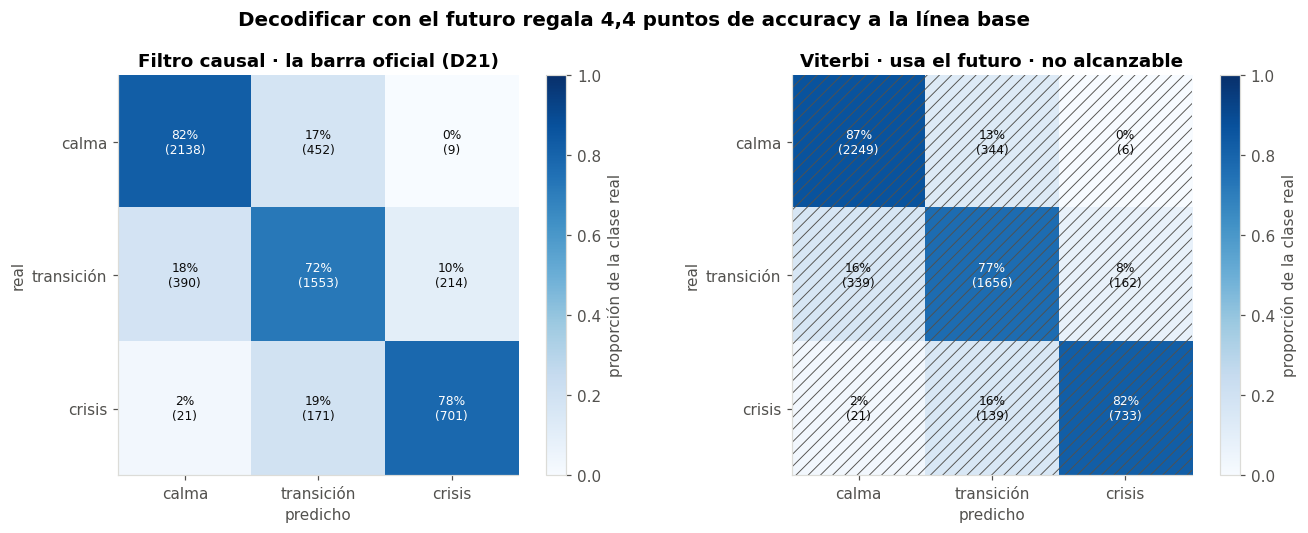

In [18]:
hay = regimen_futuro.notna()
y_reg = regimen_futuro[hay].astype(int)
regimen_causal = etiquetador.predict_causal(etiquetado)
base_causal = evaluacion.linea_base_persistencia(y_reg, regimen_causal[hay], etiquetador.n_estados)
base = evaluacion.linea_base_persistencia(y_reg, regimen[hay], etiquetador.n_estados)

fig, ejes = plt.subplots(1, 2, figsize=(12.4, 4.9))
viz.confusion(evaluacion.matriz_confusion(y_reg, regimen_causal[hay], etiquetador.n_estados),
              "Filtro causal · la barra oficial (D21)", eje=ejes[0])
viz.confusion(evaluacion.matriz_confusion(y_reg, regimen[hay], etiquetador.n_estados),
              "Viterbi · usa el futuro · no alcanzable", eje=ejes[1])
ejes[1].add_patch(plt.Rectangle((-0.5, -0.5), etiquetador.n_estados, etiquetador.n_estados,
                                facecolor="none", hatch="///", linewidth=0,
                                edgecolor=viz.TINTA_SECUNDARIA, zorder=2))
fig.suptitle("Decodificar con el futuro regala {:.1f} puntos de accuracy a la línea base".format(
    100 * (base["accuracy"] - base_causal["accuracy"])).replace(".", ","),
    fontsize=13, fontweight="bold")
viz.guardar(fig, "01_persistencia_causal_vs_viterbi")
# Mismo fichero bajo el nombre heredado: `docs/metodologia/etiquetado_regimenes.md`
# referencia `linea_base_persistencia.png` y no se renombra (R10).
viz.guardar(fig, "linea_base_persistencia")

## Qué se lleva el resto del proyecto

- **La etiqueta.** `regimen_futuro`: el régimen dominante de las 21 sesiones
  siguientes, con la crisis como clase minoritaria. Es lo que justifica el taller
  entero; la cifra la imprime la última celda.
- **El etiquetador entero**, no solo las etiquetas: el cuaderno 14 tiene que poder
  etiquetar series sintéticas con el mismo criterio exacto.
- **La línea base de persistencia causal** sobre la muestra completa. Ésa **no** es
  la barra del cuaderno 03, que mide sobre test, es más exigente y publica allí sus
  propias cifras: no se copian aquí para que no puedan quedarse obsoletas.
- **El tamaño muestral honesto no son las ventanas.** Las ventanas de crisis se
  agrupan en unas pocas rachas contiguas, y ése es el número que hay que citar en
  cualquier intervalo de confianza. Lo imprime la última celda.
- **Una advertencia sobre el catálogo.** `features_etiquetado` no es una lista
  cualquiera de canales: entra en un modelo gaussiano y por eso exige features
  estacionarias y sin masa puntual. Añadir una obliga a repetir el control
  bloqueante **y** el barrido de semillas, no solo a re-ejecutar.

## Salidas generadas

In [19]:
from pathlib import Path

src.DIR_METRICAS.mkdir(parents=True, exist_ok=True)

pd.concat([regimen, regimen_futuro, proba], axis=1).to_parquet(src.DIR_PROCESADO / "regimenes.parquet")
etiquetador.guardar(src.DIR_PROCESADO / "etiquetador_regimenes.pkl")
reparto.round(2).to_csv(src.DIR_METRICAS / "distribucion_regimenes.csv")
transicion.round(4).join(duracion.round(1).rename("duracion")).to_csv(src.DIR_METRICAS / "transicion_regimenes.csv")

salidas = [
    src.DIR_PROCESADO / "regimenes.parquet",
    src.DIR_PROCESADO / "etiquetador_regimenes.pkl",
    src.DIR_METRICAS / "distribucion_regimenes.csv",
    src.DIR_METRICAS / "transicion_regimenes.csv",
    src.DIR_FIGURAS / "01_patologias_features.png",
    src.DIR_FIGURAS / "01_estabilidad_semillas.png",
    src.DIR_FIGURAS / "control_etiquetado.png",
    src.DIR_FIGURAS / "01_etiquetado_por_anio.png",
    src.DIR_FIGURAS / "01_persistencia_causal_vs_viterbi.png",
    src.DIR_FIGURAS / "linea_base_persistencia.png",
]

for ruta in salidas:
    ruta = Path(ruta)
    marca = "ok" if ruta.exists() else "--"
    print("[{}] {}".format(marca, ruta.relative_to(src.RAIZ)))

[ok] data\processed\regimenes.parquet
[ok] data\processed\etiquetador_regimenes.pkl
[ok] results\metricas\distribucion_regimenes.csv
[ok] results\metricas\transicion_regimenes.csv
[ok] results\figures\01_patologias_features.png
[ok] results\figures\01_estabilidad_semillas.png
[ok] results\figures\control_etiquetado.png
[ok] results\figures\01_etiquetado_por_anio.png
[ok] results\figures\01_persistencia_causal_vs_viterbi.png
[ok] results\figures\linea_base_persistencia.png


In [20]:
print("Lo que este cuaderno entrega")
print("· clase de crisis: {:.1f} % de las ventanas etiquetadas".format(
    control.loc["peso de la clase de crisis", "medido"]))
print("· rachas contiguas de crisis en la etiqueta a {} días: {}".format(
    config.ventanas().horizonte,
    regimenes.tramos_contiguos(regimen_futuro.dropna(), etiquetador.estado_crisis)))
print("· persistencia causal sobre la muestra completa: accuracy {:.1%} · recall de crisis {:.1%}".format(
    base_causal["accuracy"], base_causal["recall_crisis"]))

Lo que este cuaderno entrega
· clase de crisis: 15.8 % de las ventanas etiquetadas
· rachas contiguas de crisis en la etiqueta a 21 días: 14
· persistencia causal sobre la muestra completa: accuracy 77.7% · recall de crisis 78.5%
